### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_19010/767131013.py:34: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


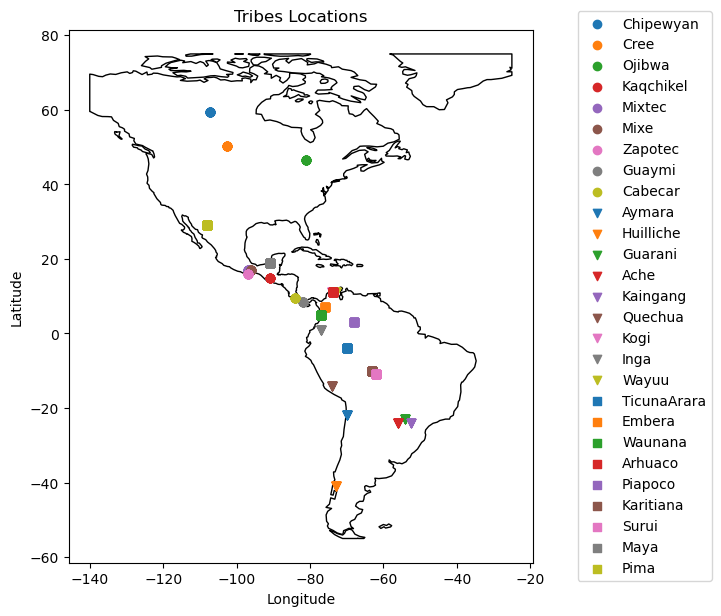

In [9]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The code visualizes the geographic distribution of Native American tribes by plotting each individual's location on a map of the Americas.

1. Preprocessing - Data loading and extraction :
First, it reads `NAm2.txt` as a space-delimited `delimiter=' '` file into a standard pandas DataFrame. From there, it extracts exactly what is needed for the map: the latitude (column 7), the longitude (column 8), and the tribe each individual belongs to (found in column 3, called `Pop`).

2. GeoDataFrame Creation :
`gpd.GeoDataFrame` wraps the regular DataFrame with geographic capabilities. 
By using `geometry=gpd.points_from_xy(longitude, latitude)`, it takes the raw coordinate columns and converts them into proper spatial geometry objects (points), enabling spatial operations and map plotting.

3. Map Rendering :
To give the data points context, it loads a world land shapefile from the `geodatasets` package (`naturalearth.land`). Since we only care about the Americas, it clips the map using a bounding box `[-140, -55, -25, 75]` (lon_min, lon_max, lat_min, lat_max) to frame just our area of interest.

4. Loop per tribe :
The code iterates over every unique tribe in `Pop` to place them on the map. It assigns:
- a marker shape cycling through `['o', 'v', 's']` (circle, triangle, square) every 9 tribes via `i//9`
- a color cycling through 9 matplotlib default colors (`colors_list[0-8]`) via `i%9`

This combination allows the code to handle up to 27 distinct tribes visually. Each tribe is plotted as its own separate scatter layer, which automatically generates a clean, organized legend.

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [10]:
import numpy as np

predictors = df.columns[8:]
X = df[predictors].values
y = df['long'].values

# Tentative de calcul de beta = (X^T X)^-1 X^T y
beta_solve = np.linalg.solve(X.T @ X, X.T @ y)


LinAlgError: Singular matrix

The rank of a matrix $X$ represents the maximum number of its linearly independent columns. 

In our dataset, we have more genetic markers ($p = 5709$) than individuals ($N = 494$). Because the number of samples is smaller than the number of predictors ($N < p$), it is mathematically impossible for all columns to be independent, which means $\text{rank}(X) < p$. 

Since the columns of $X$ are linearly dependent, the resulting square matrix $(X^\top X)$ does not have full rank. This makes it a **singular matrix**, meaning its inverse $(X^\top X)^{-1}$ simply does not exist. 

Because `np.linalg.solve` attempts to find an exact solution by essentially computing this inverse, it naturally fails and throws a `LinAlgError: Singular matrix`.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [11]:
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
print("rank(X) =", rank)
print(f"we get :{beta_lstsq.shape} estimators")
print("the first coefficients are :", beta_lstsq[:5])

rank(X) = 494
we get :(5709,) estimators
the first coefficients are : [-0.04005781 -0.01940898  0.01111306 -0.01234685 -0.02460976]


Unlike `np.linalg.solve`, the `np.linalg.lstsq` function does not raise an error.

Instead of trying to find the exact inverse of a full-rank square matrix, `lstsq` computes the least-squares solution. To do this, it uses **Singular Value Decomposition (SVD)** to find the best approximation that minimizes the Euclidean norm of the solution. 

Because of this mathematical approach, `lstsq` works perfectly fine even when our matrix is rank-deficient ($N < p$).

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [12]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
beta_sklearn = lr.coef_
print('Values  sklearn :', beta_sklearn)
print('Values  lstsq :', beta_lstsq)

Values  sklearn : [-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]
Values  lstsq : [-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


### Why do sklearn coefficients differ?

The coefficients found by **scikit-learn** may differ because the library often involves **centering the variables**.

* **Practical Reason:** By centering the predictors (mean = 0), the intercept ($\beta_0$) becomes exactly the **empirical mean** of the target variable $y$.
* **Interpretability:** The model becomes much more intuitive. The intercept represents the **expected value** (e.g., longitude) for an individual with an **"average" genetic profile**.

> **In short:** Centering simplifies the model by using the population mean as the baseline reference point.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

**Geometric interpretation:** PCA seeks to project high-dimensional data onto a lower-dimensional subspace (such as a line or a plane) in such a way that the orthogonal distance between the original data points and their projection is minimized.

**Statistical interpretation:** It consists of creating new variables (the principal components) that are linear combinations of the original variables. These new variables are uncorrelated (orthogonal) to each other. The first principal component captures the maximum possible variance in the data, the second captures the maximum remaining variance, and so on.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

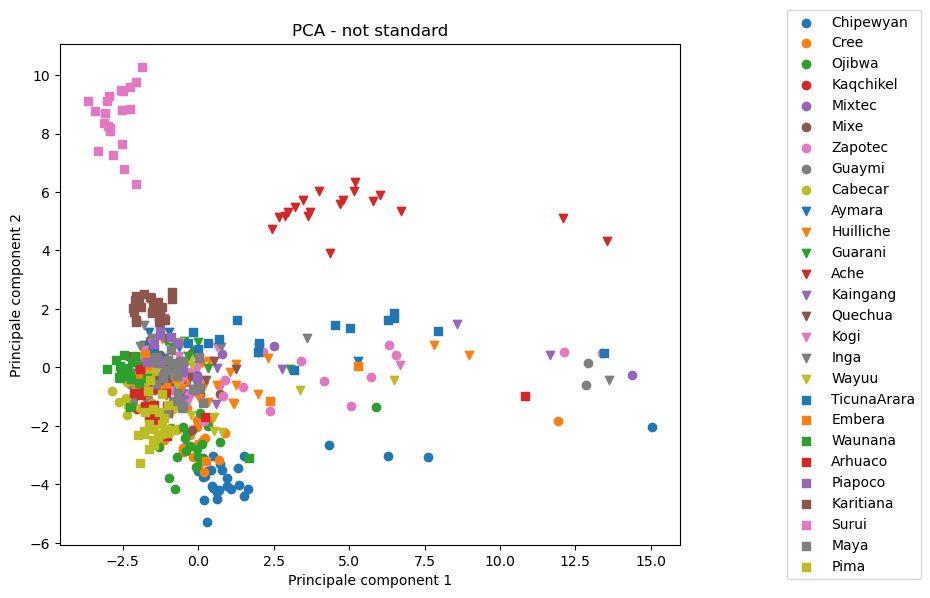

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Création du plot
fig, ax = plt.subplots(figsize=(8.0, 6.5))
for i, tribe in enumerate(gdf['Pop'].unique()):
    idx = (gdf['Pop'] == tribe).values
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('PCA - not standard')
ax.set_xlabel('Principale component 1')
ax.set_ylabel('Principale component 2')
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

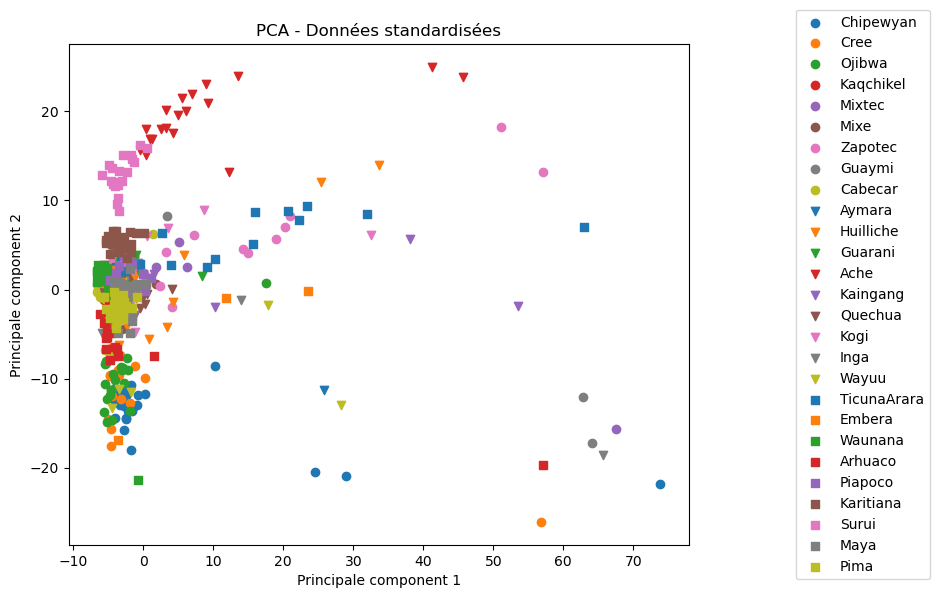

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_std)

# Création du plot
fig, ax = plt.subplots(figsize=(8.0, 6.5))
for i, tribe in enumerate(gdf['Pop'].unique()):
    idx = (gdf['Pop'] == tribe).values
    ax.scatter(X_pca_std[idx, 0], X_pca_std[idx, 1], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('PCA - Données standardisées')
ax.set_xlabel('Principale component 1')
ax.set_ylabel('Principale component 2')
plt.show()

**Comparison between Unstandardized and Standardized PCA Plots:**

Visually, the 2D scatter plot of the standardized data typically shows much clearer separation and more distinct clustering of the different tribes compared to the plot using raw data. The spatial distribution of the points changes significantly, often revealing a structure that better reflects the actual geographic or genetic divergences.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Visually, the tribal groups are much better separated and structured after standardization. 

Our genetic data is binary (encoded as 0 or 1). If some markers mutate very frequently while others mutate very rarely, their variances will be vastly different. 

Since PCA is highly sensitive to the scale of variances, standardizing the data gives each gene the same initial "weight". This prevents the PCA from being dominated solely by the most frequent mutations, ensuring a more balanced representation of the genetic structure.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

###### Principal Component Analysis (PCA) Variance

The first two components capture a low percentage of the total variance (often **< 10%** in high-dimensional genetic datasets). 

* **Information Retention:** To retain a majority of the information (e.g., **80%** or **90%** of the variance), the cumulative variance plot indicates that several hundred components would be required.
* **Complexity:** This highlights the high dimensionality of genetic data, where signal is distributed across many subtle variations rather than a few dominant factors.

**Takeaway:** While the first two PCs are useful for 2D visualization, they represent only a small fraction of the total genetic diversity in the sample.

Variance captured by the first 2 components: 3.39%


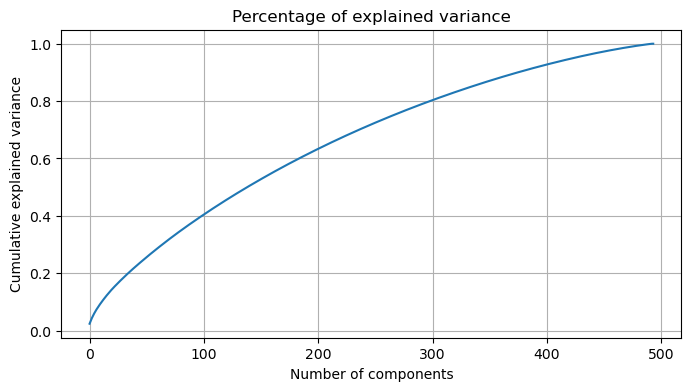

In [16]:
pca_full = PCA().fit(X_std)
variance_ratio = pca_full.explained_variance_ratio_

# Print the variance captured by just the first two principal components
print(f"Variance captured by the first 2 components: {sum(variance_ratio[:2])*100:.2f}%")

# Plot the cumulative explained variance

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(variance_ratio))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Percentage of explained variance')
plt.grid(True)
plt.show()

The first two principal components capture a very small percentage of the total variance (often < 10% in this type of high-dimensional genetic data). 

To retain a majority of the information (e.g., 80% or 90% of the variance), the cumulative variance plot shows that we would need to keep several hundred principal components.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

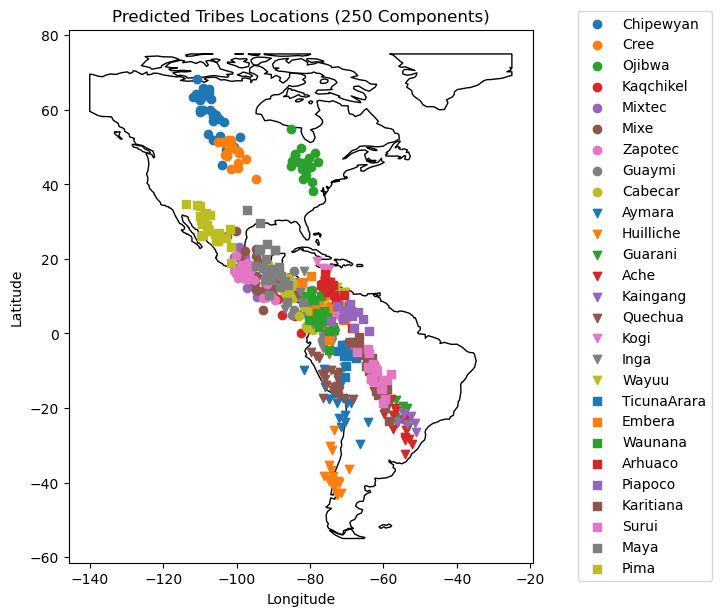

In [17]:
from sklearn.linear_model import LinearRegression

# Combine latitude and longitude into a single target array
y_coords = df[['lat', 'long']].values

# Perform PCA with 250 components
pca_250 = PCA(n_components=250)
X_pca_250 = pca_250.fit_transform(X_std)

# Fit a multiple linear regression model
lr_250 = LinearRegression()
lr_250.fit(X_pca_250, y_coords)

# Predict the coordinates
y_pred_250 = lr_250.predict(X_pca_250)

# Create a GeoDataFrame for the PREDICTED coordinates
gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(y_pred_250[:, 1], y_pred_250[:, 0]))

# Plotting the predicted coordinates
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    # Note: we use the predicted geometry here
    ax.scatter(members_tribe.geometry.x, members_tribe.geometry.y, 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations (250 Components)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

**Conclusion:**
By using 250 principal components, the map of predicted locations looks almost identical to the true geographic locations. 

However, this result is dangerously optimistic. Because we are evaluating the model on the exact same data it was trained on, the model is severely overfitting. With 250 dimensions, the model has enough capacity to essentially "memorize" the training points. This map does not represent the model's true ability to find the geographical origin of new, unseen individuals.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [18]:
from sklearn.metrics.pairwise import haversine_distances

# Haversine function expects inputs in radians
y_coords_rad = np.radians(y_coords)
y_pred_rad = np.radians(y_pred_250)

# Calculate pairwise distances and extract the diagonal (distance between true and predicted point for each individual)
distances_mat = haversine_distances(y_coords_rad, y_pred_rad)
# Multiply by Earth's radius in km (approx 6371 km)
distances_km = np.diag(distances_mat) * 6371

mean_error_km = np.mean(distances_km)
print(f"Mean training error with 250 components: {mean_error_km:.2f} km")

Mean training error with 250 components: 490.99 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**Cross-validation** is a resampling procedure used to evaluate machine learning models on a limited data sample. The dataset is divided into $K$ subsets (or "folds"). The model is trained on $K-1$ folds and tested on the remaining fold. This process is repeated $K$ times, and the test errors are averaged.

This is crucial because it gives a realistic estimate of how the model will perform on completely unseen data (generalization), preventing the illusion of success caused by overfitting. 

When dealing with non-IID data (not Independent and Identically Distributed), such as genetic data clustered by families or tribes, standard random splitting can cause "data leakage" (e.g., placing siblings in both the train and test sets). To handle this, group-based strategies must be used to ensure entire groups are kept together in either the training or testing phase.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Given that our individuals belong to specific tribes (`Pop` column) and countries, a standard random `KFold` might result in data leakage by splitting members of the same tribe across training and test sets. 

The most adequate cross-validation iterator for this context is **`GroupKFold`**. By using the tribe as the group parameter, `GroupKFold` guarantees that all individuals from a specific tribe are either entirely in the training set or entirely in the test set. This strictly tests the model's ability to generalize to completely new, unseen populations.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_predict

# Using KFold with shuffle to break the dataset order
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Create a pipeline to avoid data leakage during the PCA step
pcr_4 = make_pipeline(StandardScaler(), PCA(n_components=4), LinearRegression())

# Get out-of-fold predictions using cross_val_predict
y_pred_cv = cross_val_predict(pcr_4, X, y_coords, cv=cv)

# Calculate the Haversine error on the out-of-fold predictions
y_pred_cv_rad = np.radians(y_pred_cv)
distances_cv_km = np.diag(haversine_distances(y_coords_rad, y_pred_cv_rad)) * 6371

print(f"Mean CV test error with 4 components: {np.mean(distances_cv_km):.2f} km")

Mean CV test error with 4 components: 2035.03 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

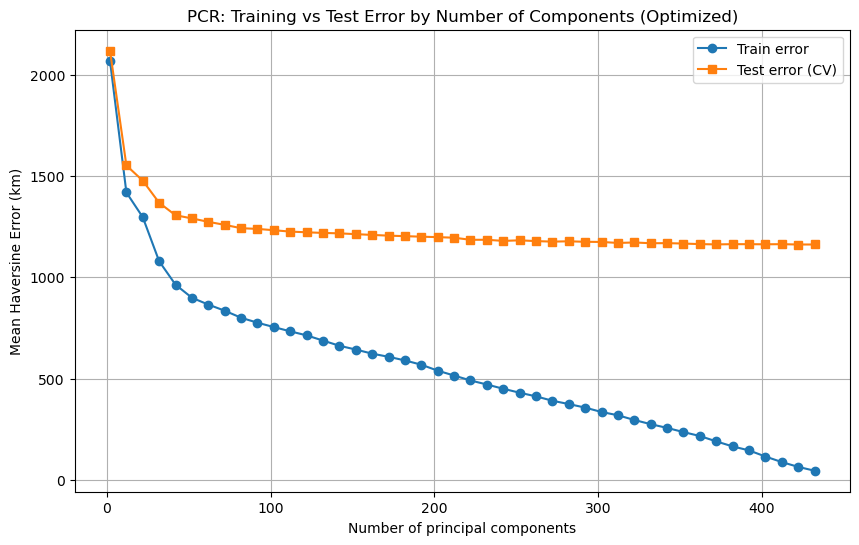

In [22]:
n_components_list = list(range(2, 442, 10))
max_components = max(n_components_list)

# Dictionaries to store errors for each n across all folds
train_errors_per_n = {n: [] for n in n_components_list}
test_errors_per_n = {n: [] for n in n_components_list}

# 2. Iterate through each fold manually to optimize PCA
for train_idx, test_idx in cv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_coords[train_idx], y_coords[test_idx]
    
    # Step A: Scale the data ONCE per fold to avoid data leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Step B: Compute PCA ONCE per fold up to the maximum needed components (440)
    pca = PCA(n_components=max_components)
    X_train_pca_full = pca.fit_transform(X_train_scaled)
    X_test_pca_full = pca.transform(X_test_scaled)
    
    # Step C: Iterate over the different values of n
    for n in n_components_list:
        # Optimization: Just slice the first n columns of the already computed PCA!
        X_train_n = X_train_pca_full[:, :n]
        X_test_n = X_test_pca_full[:, :n]
        
        # Fit the Linear Regression on this slice
        lr = LinearRegression()
        lr.fit(X_train_n, y_train)
        
        # Predict
        y_train_pred = lr.predict(X_train_n)
        y_test_pred = lr.predict(X_test_n)
        
        # Calculate Haversine errors in km
        train_dist = np.mean(np.diag(haversine_distances(np.radians(y_train), np.radians(y_train_pred))) * 6371)
        test_dist = np.mean(np.diag(haversine_distances(np.radians(y_test), np.radians(y_test_pred))) * 6371)
        
        # Store results
        train_errors_per_n[n].append(train_dist)
        test_errors_per_n[n].append(test_dist)

# 3. Average the errors across all 10 folds for each n
train_errors = [np.mean(train_errors_per_n[n]) for n in n_components_list]
test_errors = [np.mean(test_errors_per_n[n]) for n in n_components_list]

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(n_components_list, train_errors, label="Train error", marker='o')
plt.plot(n_components_list, test_errors, label="Test error (CV)", marker='s')
plt.xlabel("Number of principal components")
plt.ylabel("Mean Haversine Error (km)")
plt.title("PCR: Training vs Test Error by Number of Components (Optimized)")
plt.legend()
plt.grid(True)
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

**Model Selection:**
I would keep the model with the number of components that minimizes the Test Error (CV) curve. Based on the plot, this optimal number is likely around 60 to 100 components (you should check the exact minimum on your generated plot).

If we continue to add components beyond this point, the training error continues to approach zero, but the test error drastically increases. This is a classic demonstration of the "curse of dimensionality" and overfitting: the model starts learning the noise of the training data rather than the actual underlying geographical-genetic patterns.

*(Note: Run the exact optimal component count through the plotting code from 4(a) using `cross_val_predict` to generate your final map).*

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.